In [101]:
# Part 1 - Setup a Notebook to Brief Your Stakeholders
# 1. Create a Jupyter Notebook to track your results.

In [102]:
# 2. At the top of the notebook, add:
# 	A short title and your name.
# 	The business question written in your own words.

# G, Jay, Sean
# Do Loyalty App users spend more than Non-Users?

In [103]:
# 3. Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from scipy import stats

In [104]:
# Load freshmart_spend.csv into a DataFrame named spend_df.
FIXED_COSTS = 292000
df = pd.read_csv("data/freshmart.csv")

In [105]:
# 5. Display:
# .head() – peek at the first rows.
# .info() – check dtypes and nulls.
# .describe() grouped by group – compare means and medians.

df.head()

,group,spend
0,App User,65.450712
1,App User,55.926035
2,App User,67.715328
3,App User,80.845448
4,App User,54.487699


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   group   400 non-null    object 
 1   spend   400 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.4+ KB


In [107]:
df.groupby("group").describe()

spend                                                         \
          count       mean        std        min        25%        50%   
group                                                                    
App User  200.0  57.388436  13.965059  18.703823  47.423085  57.937122   
Non-User  200.0  53.288023  14.805057   3.380990  42.912437  53.182590   

                                 
                75%         max  
group                            
App User  65.512787   98.802537  
Non-User  62.308467  109.790972

In [108]:
AU_MEAN = 57.38
NU_MEAN = 53.28

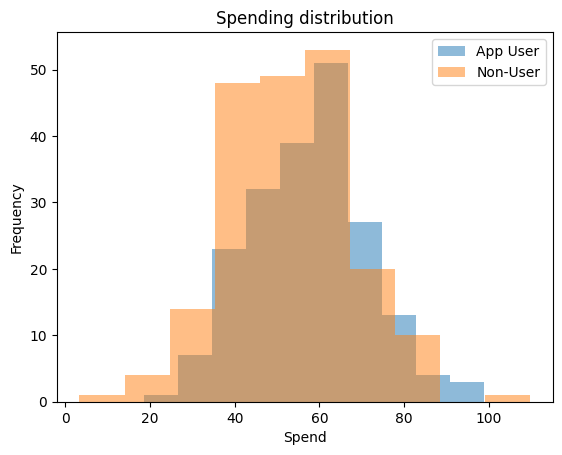

In [109]:
# 6. Visual checks for normality (one plot for each group):
# A histogram or a boxplot.
# Hints: Look for symmetry and extreme outliers.

fig, ax = plt.subplots()
ax.hist(df[df['group'] == 'App User']['spend'], alpha=0.5, label='App User')
ax.hist(df[df['group'] == 'Non-User']['spend'], alpha=0.5, label='Non-User')
ax.set_title('Spending distribution')
ax.set_xlabel('Spend')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

In [110]:
# 7. Write one or two sentences on whether normality seems reasonable for a t-test.

It looks like a normal distribution. Reasonable outliers.

In [111]:
# Part 2 – Independent t-Test
# FreshMart wants solid evidence that app users spend more.

# 1. Set up hypotheses in plain language and symbols:
# 	(Null Hypothesis) H₀: μ₁ = μ₂
# 	(Alternative Hypothesis) H₁: μ₁ > μ₂

# Null Hypothesis: App had no effect on app users, so they spent same amount as non-users.
# Alternative Hypothesis: App had effect on making app users spend more than non-users.

In [112]:
# 2. Run stats.ttest_ind() with equal_var=False (Welch’s test handles unequal variances).
au_df = df[df["group"] == "App User"]
nu_df = df[df["group"] == "Non-User"]

ttest = stats.ttest_ind(au_df["spend"], nu_df["spend"], equal_var=False)

# 3. Print the test statistic and p-value.
print(ttest)

TtestResult(statistic=np.float64(2.849252420752362), pvalue=np.float64(0.004610620601609665), df=np.float64(396.6497915124304))


In [113]:
# 4. Decide:
# Is p < 0.05?
# Interpret your p-value and test results.

# Our p-value is 0.00, much less than 0.05.
# It means that the t-statistic of 2.85 is not random.

In [114]:
# 5. Explain any important information you learned from you test results
# to the stakeholders for FreshMart in a few sentences.

# App users performed better than non-users.
# There was significant difference in the average spends of the groups, and it was not by random chance.

In [115]:
# Part 3 – Simulating Best-Case and Worst-Case Monthly Profit
# 1. Use the mean and standard deviation for each group that you observed in your sample.
# 	Hint: your loc and scale for your normal distribution should be derived
# 	from the mean and std of your samples in the freshmart_spend.csv

# App users: 57.388436	13.965059
au_normal = np.random.normal(loc=57.388436, scale=13.965059)
au_mean = np.mean(au_normal)
# Non-users: 53.288023	14.805057
nu_normal = np.random.normal(loc=53.288023, scale=14.805057)
nu_mean = np.mean(nu_normal)

In [116]:
print(au_mean, nu_mean)

55.62461094693802 87.1610171669177


In [117]:
# 2. Assume for this month:
# 	1,000 App Users will visit.
# 	5,000 Non-Users will visit.
# 	The business has fixed costs of $292,000 this month.

[np.float64(57083.31235832898), np.float64(58141.325515056255), np.float64(56851.54022807483), np.float64(57116.61687664472), np.float64(56569.5552151874), np.float64(57380.101200762605), np.float64(57346.59620118028), np.float64(57402.56852331631), np.float64(57295.97224822754), np.float64(57824.784265385766), np.float64(57481.38377761735), np.float64(56415.36114405708), np.float64(57862.69163002391), np.float64(57813.219633514), np.float64(57826.16875270314), np.float64(57807.807199831106), np.float64(57190.06559103819), np.float64(57746.622373217644), np.float64(57639.98552710582), np.float64(57516.3540289979), np.float64(56998.271068358925), np.float64(57001.98197407245), np.float64(56798.819001863136), np.float64(56891.3624849015), np.float64(56966.89148169083), np.float64(57427.286289509124), np.float64(57647.27641894208), np.float64(58253.06445253483), np.float64(57789.04906938682), np.float64(57454.29101880724), np.float64(56532.19413374027), np.float64(56975.194318566675), np.

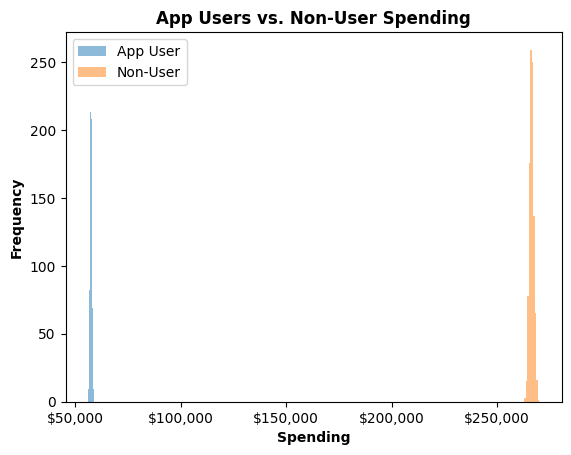

In [136]:
# 3. Simulate 1,000 scenarios for total revenue:
# 	The simulation should simulate the individual spending for 1,000 App Users plus the individual spending for 5,000 Non-App Users.
# 	You should do this simulation of both groups 1,000 times.
# 	For each scenario, draw 1,000 spending amounts for App Users from a normal distribution (use your sample mean and std).
# 	Draw 5,000 spending amounts for Non-Users from a normal distribution (use your sample mean and std).

# 4. Subtract the fixed cost from each scenario’s total revenue to get profit.
# 	Hint: Locate the fixed costs for the business above
# 	Sum both to get total revenue for that scenario.

def simulation(app_user_count, non_user_count, au_mean, nu_mean, repetitions):

	au_list = []
	nu_list = []
	revenue_list = []
	mean_list = []

	# Set up loop
	while repetitions > 0:

		# Normal distributions for both groups
		au_normal = np.random.normal(loc=au_mean, scale=13.965059, size=app_user_count)
		nu_normal = np.random.normal(loc=nu_mean, scale=14.805057, size=non_user_count)

		# Sum the trials
		au_sum = au_normal.sum()
		nu_sum = nu_normal.sum()

		# Add the sum to a list
		au_list.append(au_sum)
		nu_list.append(nu_sum)

		# Subtract the fixed cost from sum
		revenue = (au_sum + nu_sum) - 292000

		# Add revenue to list
		revenue_list.append(revenue)
		mean_list.append(np.mean(revenue))
		# Decrement loop counter
		repetitions -= 1

	# Returns three numbers
	mean_array = np.array(mean_list)
	return au_list, nu_list, revenue_list, mean_array

thousand_au, thousand_nu, thousand_rev, thousand_mean = simulation(1000, 5000, au_mean=AU_MEAN, nu_mean=NU_MEAN, repetitions=1000)
print(thousand_au, thousand_nu)

# Histogram check
fig, ax = plt.subplots()
ax.hist(thousand_au, alpha=0.5, label='App User')
ax.hist(thousand_nu, alpha=0.5, label='Non-User')
ax.set_title("App Users vs. Non-User Spending", weight="bold")
ax.set_xlabel('Spending', weight="bold")
ax.set_ylabel('Frequency', weight="bold")
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.legend()
plt.show()

In [119]:
print(thousand_rev)

[np.float64(197267.14507092902), np.float64(200710.59835941164), np.float64(200400.15207280283), np.float64(197433.0278343851), np.float64(199655.6329501309), np.float64(199247.32536078285), np.float64(199142.5105165193), np.float64(199068.25239972182), np.float64(199592.82746453007), np.float64(199212.1718677603), np.float64(198737.35089313833), np.float64(198963.05596669763), np.float64(200909.91752799123), np.float64(198539.8162521156), np.float64(200816.3660306767), np.float64(201002.22527445183), np.float64(198756.56845516816), np.float64(198731.79357060348), np.float64(199745.63642829267), np.float64(198631.6202089385), np.float64(198703.0719028946), np.float64(198836.57200490416), np.float64(200022.52688808285), np.float64(198761.7971021086), np.float64(201182.7098286819), np.float64(199580.2510635025), np.float64(199779.0368345427), np.float64(199554.23337976373), np.float64(200756.06833192607), np.float64(199940.41578099853), np.float64(200745.33842351096), np.float64(197296.6

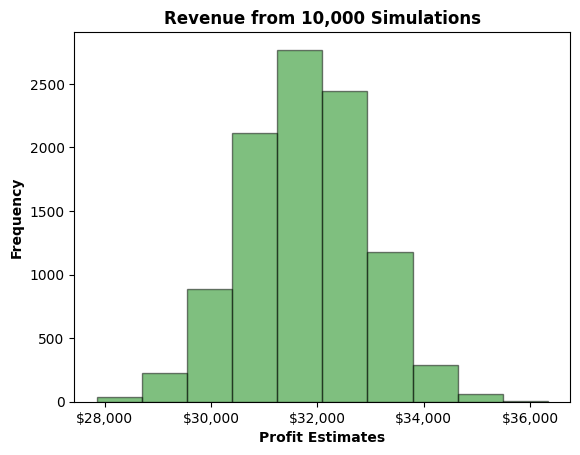

In [133]:
# 5. Plot a histogram of the 10,000 profit estimates.
tent_au, tent_nu, tent_rev, tent_mean = simulation(1000, 5000, au_mean=AU_MEAN, nu_mean=NU_MEAN, repetitions=10000)

# Histogram check
fig, ax = plt.subplots()
ax.hist(tent_rev, alpha=0.5, edgecolor="black", color="green")
ax.set_title("Revenue from 10,000 Simulations", weight="bold")
ax.set_xlabel('Profit Estimates', weight="bold")
ax.set_ylabel('Frequency', weight="bold")
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.show()

TypeError: unsupported operand type(s) for -: 'list' and 'list'

In [121]:
# 6. Answer:
# What is the average simulated profit?
print(np.mean(tent_rev))

31785.96784586562


In [122]:
# What are the 5th and 95th percentiles of the simulated profit?
low, high = np.percentile(tent_rev, [2.5, 97.5])
print("5th and 95th Percentiles:", low, high)

5th and 95th Percentiles: 29574.330883557803 34023.42207677174


In [123]:
# Explain how we could use this information to guide future spending decisions.
# In the 5th percent worst case, how much money could they reasonably risk spending
# if they wanted to remain profitable for shareholders?
best = 292000 - high
worst = 292000 - low
print("Worst case:", worst, "\nBest case:", best)

Worst case: 262425.6691164422 
Best case: 257976.57792322827


In [124]:
best_operating_margin = FIXED_COSTS - best
worst_operating_margin = FIXED_COSTS - worst
print(f"""Best operating margins:  {best_operating_margin:.2f}
Worst operating margins: {worst_operating_margin:.2f}""")

Best operating margins:  34023.42
Worst operating margins: 29574.33


Impact of a $5 Decrease Repeat the profit simulation assuming that both App Users and Non-Users spend $5 less on average. How does this affect the average profit and risk of a loss?

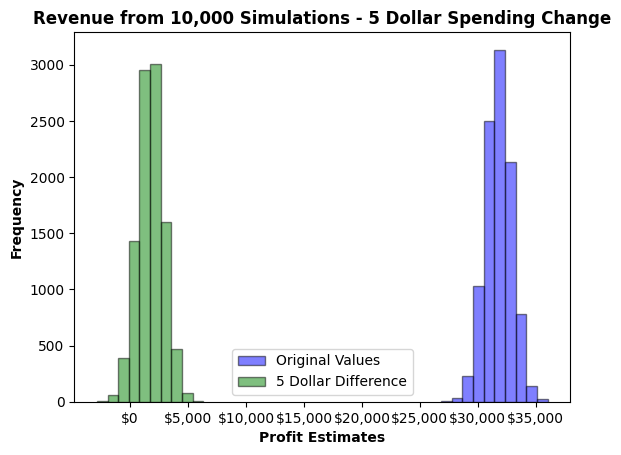

In [ ]:
tent_au_5, tent_nu_5, tent_rev_5, tent_rev_5 = simulation(1000, 5000, au_mean=AU_MEAN-5, nu_mean=NU_MEAN-5, repetitions=10000)

# Histogram check
fig, ax = plt.subplots()
ax.hist(tent_rev, alpha=0.5, edgecolor='black', color='blue', label='Original Values')
ax.hist(tent_rev_5, alpha=0.5, edgecolor="black", color="green", label='5 Dollar Difference')
ax.set_title("Revenue from 10,000 Simulations - 5 Dollar Spending Change", weight="bold")
ax.set_xlabel('Profit Estimates', weight="bold")
ax.set_ylabel('Frequency', weight="bold")
ax.legend()
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.show()

In [137]:
orig_au, orig_nu, orig_rev, orig_mean = simulation(1000, 5000, au_mean=AU_MEAN, nu_mean=NU_MEAN, repetitions=5000)

In [138]:
orig_au_5, orig_nu_5, orig_rev_5, orig_mean_5 = simulation(1000, 5000, au_mean=AU_MEAN, nu_mean=NU_MEAN, repetitions=5000)

In [141]:
mean_diff = orig_mean - orig_mean_5

In [142]:
print(mean_diff)

[  238.26016785   636.61545828  2129.59948655 ...  1073.85997092
  1542.16384996 -1850.48760275]
